<a href="https://colab.research.google.com/github/LucioFassarella/VQE/blob/main/VQE_Hamiltoniano_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="red"><b>Auto-solucionador Quântico Variacional - _VQE_</b></font>

<center><img align = "center" src="https://drive.google.com/uc?export=view&id=1usXrPscUXzfQF5wNtkvuVGARuuhcgyw-" alt="grafo" width="500"></center>

<center>"You never understand things. You just get used to them." (John von Neumann)</center>

---

<font color = "orange">**Qiskit**:</font>
*   [Python's Instalation](https://pypi.org/project/qiskit/)
*   [IBM Quantum cloud](https://quantum.cloud.ibm.com/)
    *   [Qiskit connect](https://cloud.ibm.com/docs/quantum-computing?topic=quantum-computing-get-started) (IBM Runtime Service)
       *   [Getting Started](https://cloud.ibm.com/docs/quantum-computing?topic=quantum-computing-get-started)
*   [Qiskit](https://docs.quantum.ibm.com/api/qiskit)
    *   [Qiskit Quantum Circuit](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit)
    *   [Qiskit Circuit Library](https://docs.quantum.ibm.com/api/qiskit/circuit_library)
    *   [Qiskit Gates Tutorial](https://github.com/Qiskit/qiskit-tutorials/blob/master/tutorials/circuits/3_summary_of_quantum_operations.ipynb)
    *   [List of Quantum Logic Gates](https://en.wikipedia.org/wiki/List_of_quantum_logic_gates)

[<font color="orange">**Execution modes**</font>](https://quantum.cloud.ibm.com/docs/en/guides/execution-modes)

*	[Choose the execution mode](https://quantum.cloud.ibm.com/docs/en/guides/choose-execution-mode)
*   [Single Job](https://quantum.cloud.ibm.com/docs/en/guides/primitives-examples#estimator-examples)
*	[Batch mode](https://quantum.cloud.ibm.com/docs/en/guides/run-jobs-batch)
*	[Section mode](https://quantum.cloud.ibm.com/docs/en/guides/run-jobs-session)
*	[Primitives examples](https://quantum.cloud.ibm.com/docs/en/guides/primitives-examples)


[<font color="green">**Local simulators**</font>](https://quantum.cloud.ibm.com/docs/en/migration-guides/local-simulators)

---

⏬

*	**Qiskit**:
	*	*How can I create a custom gate from a matrix? 1 Minute Qiskit*. Youtube, 05 set. 2022.
            URL: [https://youtu.be/zFgyMGklANM?si=oCxxGYBFQ0OCoCaL](https://youtu.be/zFgyMGklANM?si=oCxxGYBFQ0OCoCaL).
	*	*How do I convert a circuito to a Gate? 1 Minute Qiskit*. Youtube, 20 abr. 2020.
            URL: [https://youtu.be/krhPpzkT_z4?si=baTxDQKybfb1SQHZ](https://youtu.be/krhPpzkT_z4?si=baTxDQKybfb1SQHZ).
	*	*How can I create a custom controlled gate? - 1 Minute Qiskit*. Youtube, 31 out. 2022. URL:
            [https://youtu.be/wHQiB95hu-E?si=toFulZ7ngFyb5F6_](https://youtu.be/wHQiB95hu-E?si=toFulZ7ngFyb5F6_).

    *   <i>How can I invert a unitary circuit? 1 Minute Qiskit </i>. Youtube, Oct 26, 2020. URL: <a href= "https://youtu.be/SiPF2SVb7xc?si=u-WxR1BOBC6lICFH" target="_blank">https://youtu.be/SiPF2SVb7xc?si=u-WxR1BOBC6lICFH</a>

## QISKIT: Carregamento

In [95]:
!pip install qiskit -U
!pip install qiskit_aer -U
!pip install qiskit-ibm-runtime -U

!pip install matplotlib
!pip install pylatexenc

import qiskit
qiskit.__version__

'2.4.1'

In [96]:
# Qiskit: métodos básicos

from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

from qiskit import transpile

from qiskit.visualization import plot_histogram, array_to_latex, plot_state_city

## Quiskit Estimadores

*   EstimatorV2: [https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/runtime-service](https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/runtime-service)
*   BaseEstimatorV2: [https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.BaseEstimatorV2](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.BaseEstimatorV2)
*   StatevectorEstimator: [https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.StatevectorEstimator](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.StatevectorEstimator)

In [97]:
# Métodos para construir circuitos
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister, Parameter

# Método para realizar experimentos ou simulações
from qiskit_ibm_runtime import Session
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Métodos para construir operadores hermitianos
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import real_amplitudes

# Transpilador
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Simulador local
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

# Experimento na IBM
from qiskit_ibm_runtime import QiskitRuntimeService, Session

# Métodos auxiliares
import numpy as np

# Método para otimização clássica
import scipy as sp
from scipy.optimize import minimize

# Método para registro de horário
import time

# Auto-solucionador Quântico Variacional (*Variational Quantum Eigensolver* - VQE)

Hamiltoniano:

$$
H
$$

Estado parametrizado:

$$
| \psi(\vec{\theta}) \rangle
$$

Valor esperado:

$$
E(\vec{\theta}) = \langle \psi(\vec{\theta}) | H | \psi(\vec{\theta}) \rangle
$$

Problema do estado fundamental:

$$
\text{minimizar}\ E(\vec{\theta}).
$$

In [98]:
# Valor esperado parametrizado

def E_parametrico(estado_qc, observavel_op, params_estado_qc = None, params_observavel_op = None, aer_flag = None, backend = None, shots = None):

    '''
    Método que fornece uma estimativa experimental do valor esperado de um
    observável relativo a um estado quântico.

    Entradas:
        estado_qc (QuantumCircuit): circuito parametrizado que prepara o estado
                                    quântico
        observavel_op (SparsePauliOp): observável hermitiano parametrizado

        params_estado_qc (list).........: lista de parâmetros do circuito que prepara
                                        o estado quântico
        params_observavel_op (list).....: lista de parâmetros (coeficientes) do
                                        observável
        aer_flag (bol)...............: None or True realiza simulação no AerSimulator

        backend (backend)............: + aer_flag = False -> realiza experimentos
                                        quânticos no backend fornecido
        shots (int)..................: número de experimentos por simulação

    Saída:
        expval (float): valor esperado
    '''

    # Cópia do circuito que prepara o estado quântico
    qc = estado_qc.copy()
    observavel = observavel_op.copy()

    # Atribuição de valores aos parâmetros do circuito
    if params_estado_qc is None:
        pass
    else:
        parametros_estado = qc.parameters[::-1] # A lista sai invertida, por isso é preciso inverter para acertar!
        dicio_params_estado = {parametros_estado[k] : params_estado_qc[k] for k in range(len(params_estado_qc))}
        qc = qc.assign_parameters(dicio_params_estado)

    if params_observavel_op is None:
        pass
    else:
        parametros_observavel = observavel_op.parameters
        dicio_params_observavel = {parametros_observavel[k] : complex(params_observavel_op[k]) for k in range(len(params_observavel_op))}
        observavel = observavel.assign_parameters(dicio_params_observavel)

    if shots is None:
        shots = 2**10

    if aer_flag is None or True:

        # Inicialização do AerSimulator
        aer_simulator = AerSimulator()
        pm = generate_preset_pass_manager(backend = aer_simulator, optimization_level=1)

        # Transpilação do circuito
        isa_qc = pm.run(qc)

        # Transpilação do observável
        isa_observavel = observavel.apply_layout(isa_qc.layout) # Changed from observavel_op to observavel

        # Execução do circuito:
        with Session(backend = aer_simulator) as session:
            estimator = Estimator(mode = session)
            estimator.options.resilience_level = 1
            job = estimator.run([(isa_qc, isa_observavel, )])
            pub_result = job.result()[0]
            expval = pub_result.data.evs

    else:
        expval = None # Ensure expval is defined if aer is False

    return expval

# Exemplo 1

$$
s \in \mathbb{R} \leadsto H = \begin{bmatrix}
1 & s\\
s & -1
\end{bmatrix} = Z + sX.
$$

Autovalores e autoestados:

$$
e_0 = - \sqrt{1 + s^2} \leadsto %
|e_0\rangle = \frac{1}{\eta_0}\begin{bmatrix}
\frac{1 - \sqrt{1+s^2}}{s}\\
1
\end{bmatrix};\ \eta_0 = \frac{\sqrt{2}}{s}\sqrt{1 +s^2 - \sqrt{1+s^2}}.
$$
$$
e_1 = + \sqrt{1 + s^2} \leadsto %
|e_1\rangle = \frac{1}{\eta_1}\begin{bmatrix}
\frac{1 + \sqrt{1+s^2}}{s}\\
1
\end{bmatrix}; \eta_1 = \frac{\sqrt{2}}{s}\sqrt{1 +s^2 + \sqrt{1+s^2}}.
$$

Energia do estado fundamental:
$$
e_0 = - \sqrt{1 + s^2}.
$$

In [99]:
'''
Cálculos matriciais no Sympy
'''

import sympy
from sympy import simplify
from sympy import Matrix, symbols, sin, cos, exp, I
from sympy.physics.quantum import Dagger
from sympy.physics.quantum.constants import hbar

s_matrix = symbols('s')

H_matrix = Matrix([[1, s_matrix], [s_matrix, -1]])

print("Matrix H:")
sympy.pprint(H_matrix)

autovalores = H_matrix.eigenvals()
print("Autovalores:")
sympy.pprint(autovalores)

autoestados = H_matrix.eigenvects()
print("Autoestados:")
sympy.pprint(autoestados)

# Estado fundamental
autoestado_minimal = autoestados[0][2][0]
# Calculate the magnitude (norm) of the eigenvector
eta_0 = sympy.sqrt(autoestado_minimal[0]**2 + autoestado_minimal[1]**2)

# Normalize the eigenvector by dividing by its magnitude
estado_fundamental = (1/eta_0)*autoestado_minimal

print("Estado fundamental:")
sympy.pprint(estado_fundamental)

# Energia fundamental:
energia_fundamental = -sympy.sqrt(1 + s_matrix**2)
print("Energia fundamental:")
sympy.pprint(energia_fundamental)

# Cálculo de valor esperado em vetor de estado

Ket_0 = Matrix([1, 0])
Ket_1 = Matrix([0, 1])

def U(theta, phi, lambd):
    return Matrix([[cos(theta/2), -exp(I*lambd)*sin(theta/2)],
     [exp(I*phi)*sin(theta/2), exp(I*(phi+lambd))*cos(theta/2)]])

print("Matriz de preparação:")
theta, phi, lambd = symbols('theta phi lambda')
sympy.pprint(U(theta, phi, lambd))

def Expval(s_param, theta, phi, lambd):
    Hs = H_matrix.subs(s_matrix, s_param)
    vetorestado = U(theta, phi, lambd)*Ket_0
    expval = Dagger(vetorestado)*Hs*vetorestado
    return expval

print("Expval:")
sympy.pprint(Expval(s_matrix, theta, phi, lambd))

Matrix H:
⎡1  s ⎤
⎢     ⎥
⎣s  -1⎦
Autovalores:
⎧    ________        ________   ⎫
⎨   ╱  2            ╱  2        ⎬
⎩-╲╱  s  + 1 : 1, ╲╱  s  + 1 : 1⎭
Autoestados:
⎡⎛                 ⎡⎡     ________    ⎤⎤⎞  ⎛                ⎡⎡   ________    ⎤ ↪
⎢⎜    ________     ⎢⎢    ╱  2         ⎥⎥⎟  ⎜   ________     ⎢⎢  ╱  2         ⎥ ↪
⎢⎜   ╱  2          ⎢⎢  ╲╱  s  + 1    1⎥⎥⎟  ⎜  ╱  2          ⎢⎢╲╱  s  + 1    1⎥ ↪
⎢⎜-╲╱  s  + 1 , 1, ⎢⎢- ─────────── + ─⎥⎥⎟, ⎜╲╱  s  + 1 , 1, ⎢⎢─────────── + ─⎥ ↪
⎢⎜                 ⎢⎢       s        s⎥⎥⎟  ⎜                ⎢⎢     s        s⎥ ↪
⎢⎜                 ⎢⎢                 ⎥⎥⎟  ⎜                ⎢⎢               ⎥ ↪
⎣⎝                 ⎣⎣        1        ⎦⎦⎠  ⎝                ⎣⎣       1       ⎦ ↪

↪ ⎤⎞⎤
↪ ⎥⎟⎥
↪ ⎥⎟⎥
↪ ⎥⎟⎥
↪ ⎥⎟⎥
↪ ⎥⎟⎥
↪ ⎦⎠⎦
Estado fundamental:
⎡             ________            ⎤
⎢            ╱  2                 ⎥
⎢          ╲╱  s  + 1    1        ⎥
⎢        - ─────────── + ─        ⎥
⎢               s        s        ⎥
⎢───────────────────────────

### Testes

In [103]:
'''
Teste de E_parametrico
'''

import numpy as np

# estado_qc

theta = Parameter('theta')
phi = Parameter('phi')
lambd = Parameter('lambd')

qr = QuantumRegister(1, 'q')
estado = QuantumCircuit(qr)
estado.u(theta, phi, lambd, qr[0])

# observavel_op

s = Parameter('s')
observavel = SparsePauliOp.from_list([("Z", 1), ("X", s)])

# Execução

parametros_do_estado = [np.pi/2,np.pi/4, np.pi/8]
print(f"Parâmetros do estado: {parametros_do_estado}")
parametros_do_observavel = [1/2]
print(f"Parâmetros do observável: {parametros_do_observavel}")
expval = E_parametrico(estado_qc = estado,
                       observavel_op = observavel,
                       params_estado_qc = parametros_do_estado,
                       params_observavel_op = parametros_do_observavel,
                       aer_flag = True, backend = None, shots = 2**20)

print(f"Valor esperado do Hamiltoniano por simulação: {expval}")

'''
Valor teórico da energia
'''

# ---> Vetor de estado
theta_val, phi_val, lambd_val = parametros_do_estado
vetorestado = U(theta_val, phi_val, lambd_val)*Ket_0
s_val = parametros_do_observavel[0]
# ---> Valor esperado
expval_teorico = Expval(s_val, theta_val, phi_val, lambd_val)
print(f"Valor esperado do Hamiltoniano por cálculo analítico/numérico: {(expval_teorico).evalf()}")

print(f"Diferença teórico - experimental: {simplify(expval_teorico - expval)}")

Parâmetros do estado: [1.5707963267948966, 0.7853981633974483, 0.39269908169872414]
Parâmetros do observável: [0.5]
Valor esperado do Hamiltoniano por simulação: 0.35400390625
Valor esperado do Hamiltoniano por cálculo analítico/numérico: Matrix([[0.353553390593274 - 3.59e-18*I]])
Diferença teórico - experimental: [[-0.000450515656725992]]


## Implementação do Algoritmo VQA

### Teste 1

$$
s = 0
$$

In [106]:
'''
Estado Fundamental e Energia Fundamental Teóricos
'''

s_val = 0
print(f"Parâmetro s: {s_val}")

# ---> Hamiltoniano
print(f"Hamiltoniano com parâmetro s: {s_val}")
sympy.pprint(H_matrix.subs(s_matrix, s_val))

# ---> Vetor de estado

estado_fundamental_val = estado_fundamental.subs(s_matrix, s_val)
print("Estado fundamental:")
sympy.pprint(estado_fundamental_val)

energia_fundamental_val = energia_fundamental.subs(s_matrix, s_val)
print(f"Energia fundamental= {energia_fundamental_val}")

Parâmetro s: 0
Hamiltoniano com parâmetro s: 0
⎡1  0 ⎤
⎢     ⎥
⎣0  -1⎦
Estado fundamental:
⎡nan⎤
⎢   ⎥
⎣nan⎦
Energia fundamental= -1


Observavel:
SparsePauliOp(['Z', 'X'],
              coeffs=[(1+0j),
 <qiskit._accelerate.circuit.ParameterExpression object at 0x7d42fa8de430>])
Estado


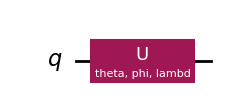

Parâmetros de preparação do estado quântico inicial do VQE: [0, 0, 0]
Parâmetros do observável: 0


/usr/local/lib/python3.12/dist-packages/qiskit_ibm_runtime/fake_provider/local_service.py:190: UserWarning: The resilience_level option has no effect in local testing mode.
  warnings.warn("The resilience_level option has no effect in local testing mode.")


Resultado da otimização:
 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -1.0
       x: [ 3.204e+00  3.410e-01  8.258e-01]
    nfev: 37
   maxcv: 0.0
********************************
Estado fundamental:


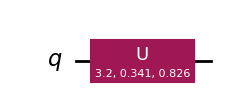

<IPython.core.display.Latex object>

Energia fundamental:
-1.0


In [111]:
'''
Implementação do VQE
'''

# Empacotamento da função E_parametrico para uso no scipy.optimize.minimize
def E_parametrico_reduzida(parametros_otimizaveis, estado_qc_fixed, observavel_op_fixed, params_observavel_op_fixed, aer_flag_fixed, backend_fixed, shots_fixed):
    # optim_params are the parameters for the quantum state preparation circuit
    return E_parametrico(estado_qc = estado_qc_fixed,
                           observavel_op = observavel_op_fixed,
                           params_estado_qc = parametros_otimizaveis,
                           params_observavel_op = params_observavel_op_fixed,
                           aer_flag = aer_flag_fixed,
                           backend = backend_fixed,
                           shots = shots_fixed)


#################################################################################

# Observavel
observavel = SparsePauliOp.from_list([("Z", 1), ("X", s)])
print("Observavel:")
print(observavel)

# Circuito de preparação do estado quântico
estado = QuantumCircuit(qr)
estado.u(theta, phi, lambd, qr[0])
print("Estado")
display(estado.draw('mpl'))

# Parâmetros de preparação do estado quântico inicial
parametros_do_estado_inicial = [0, 0, 0] # This corresponds to [t, p, l]
parametros_do_observavel = [s_val] # Use s_val from Teste 1 (s=0)
print(f"Parâmetros de preparação do estado quântico inicial do VQE: {parametros_do_estado_inicial}")
print(f"Parâmetros do observável: {s_val}")
# Loop de otimização híbrida
resultado = minimize(E_parametrico_reduzida, parametros_do_estado_inicial,
                     args=(estado, # estado_qc_fixed
                           observavel, # observavel_op_fixed
                           #parametros_do_estado, # parametros_do_estado_fixed <--- omitido para otimização
                           parametros_do_observavel, # params_observavel_op_fixed
                           True, # aer_flag_fixed
                           None, # backend_fixed
                           2**12), # shots_fixed
                     tol = 1/2**12, method="COBYLA")

print("Resultado da otimização:")
print(resultado)

'''
Impressão do estado fundamental
'''
print("********************************")

from qiskit.quantum_info import Statevector

print("Estado fundamental:")
t_val, p_val, l_val = resultado.x

estado_qc_val = estado.copy().assign_parameters({theta: t_val, phi : p_val, lambd : l_val})
display(estado_qc_val.draw('mpl'))

vetorestado = Statevector.from_instruction(estado_qc_val)
display(vetorestado.draw('latex'))

print("Energia fundamental:")
print(resultado.fun)


### Teste 2

$$
s = 1
$$

In [112]:
'''
Estado Fundamental e Energia Fundamental Teóricos
'''

s_val = 1
print(f"Parâmetro s: {s_val}")

# ---> Hamiltoniano
print(f"Hamiltoniano com parâmetro s: {s_val}")
sympy.pprint(H_matrix.subs(s_matrix, s_val))

# ---> Vetor de estado

estado_fundamental_val = estado_fundamental.subs(s_matrix, s_val)
print("Estado fundamental:")
sympy.pprint(estado_fundamental_val.evalf(12))

energia_fundamental_val = energia_fundamental.subs(s_matrix, s_val)
print(f"Energia fundamental= {energia_fundamental_val.evalf(12)}")

Parâmetro s: 1
Hamiltoniano com parâmetro s: 1
⎡1  1 ⎤
⎢     ⎥
⎣1  -1⎦
Estado fundamental:
⎡-0.382683432365⎤
⎢               ⎥
⎣0.923879532511 ⎦
Energia fundamental= -1.41421356237


Observavel:
SparsePauliOp(['Z', 'X'],
              coeffs=[(1+0j),
 <qiskit._accelerate.circuit.ParameterExpression object at 0x7d42fa6af810>])
Estado


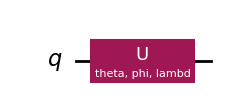

Parâmetros de preparação do estado quântico inicial do VQE: [0, 0, 0]
Parâmetros do observável: 1
Resultado da otimização:
 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -1.45068359375
       x: [-2.312e+00  1.140e-02 -3.345e-01]
    nfev: 42
   maxcv: 0.0
********************************
Estado fundamental:


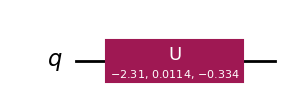

<IPython.core.display.Latex object>

Energia fundamental:
-1.45068359375


In [113]:
'''
Implementação do VQE
'''

# Empacotamento da função E_parametrico para uso no scipy.optimize.minimize
def E_parametrico_reduzida(parametros_otimizaveis, estado_qc_fixed, observavel_op_fixed, params_observavel_op_fixed, aer_flag_fixed, backend_fixed, shots_fixed):
    # optim_params are the parameters for the quantum state preparation circuit
    return E_parametrico(estado_qc = estado_qc_fixed,
                           observavel_op = observavel_op_fixed,
                           params_estado_qc = parametros_otimizaveis,
                           params_observavel_op = params_observavel_op_fixed,
                           aer_flag = aer_flag_fixed,
                           backend = backend_fixed,
                           shots = shots_fixed)


#################################################################################

# Observavel
observavel = SparsePauliOp.from_list([("Z", 1), ("X", s)])
print("Observavel:")
print(observavel)

# Circuito de preparação do estado quântico
estado = QuantumCircuit(qr)
estado.u(theta, phi, lambd, qr[0])
print("Estado")
display(estado.draw('mpl'))

# Parâmetros de preparação do estado quântico inicial
parametros_do_estado_inicial = [0, 0, 0] # This corresponds to [t, p, l]
parametros_do_observavel = [s_val] # Use s_val from Teste 1 (s=0)
print(f"Parâmetros de preparação do estado quântico inicial do VQE: {parametros_do_estado_inicial}")
print(f"Parâmetros do observável: {s_val}")
# Loop de otimização híbrida
resultado = minimize(E_parametrico_reduzida, parametros_do_estado_inicial,
                     args=(estado, # estado_qc_fixed
                           observavel, # observavel_op_fixed
                           #parametros_do_estado, # parametros_do_estado_fixed <--- omitido para otimização
                           parametros_do_observavel, # params_observavel_op_fixed
                           True, # aer_flag_fixed
                           None, # backend_fixed
                           2**12), # shots_fixed
                     tol = 1/2**12, method="COBYLA")

print("Resultado da otimização:")
print(resultado)

'''
Impressão do estado fundamental
'''
print("********************************")

from qiskit.quantum_info import Statevector

print("Estado fundamental:")
t_val, p_val, l_val = resultado.x

estado_qc_val = estado.copy().assign_parameters({theta: t_val, phi : p_val, lambd : l_val})
display(estado_qc_val.draw('mpl'))

vetorestado = Statevector.from_instruction(estado_qc_val)
display(vetorestado.draw('latex'))

print("Energia fundamental:")
print(resultado.fun)

# Exemplo 2

Fonte:
*   Luca Ion, Adam Smith: <i>Variational quantum eigensolver for chemical molecules</i>. arXiv:2512.22572v2, 2025. <a href="https://arxiv.org/abs/2512.22572v2" target = "_blank">DOI:10.48550/arXiv.2512.22572</a>.
*   Alberto Peruzzo <i>et al.</i>: <i>A variational eigenvalue solver on a photonic quantum processor</i>.  Nat. Commun. 5, 4213 (2014). <a href= "https://doi.org/10.1038/ncomms5213" target="_blank">10.1038/ncomms5213</a>.
    *   <a href="https://static-content.springer.com/esm/art%3A10.1038%2Fncomms5213/MediaObjects/41467_2014_BFncomms5213_MOESM1050_ESM.pdf" target = "_blank">Suplementary informations</a>. <font color="green"><--- Contem valores de parâmetros físicos necessários para modelagem matemática.</font>

Hamiltoniano:

$$
H = \frac{1}{2}\left\lbrack J_x(X_0 + X_1) + J_z (Z_0 + Z_1) + J_{xx}X_0X_1 + J_{zz}Z_0Z_1 + J_{xz}(X_0Z_1 + Z_0X_1) + C \right\rbrack
$$

Estado parametrizado:

$$
| \psi(\vec{\theta}) \rangle
$$

Valor esperado:

$$
E(\vec{\theta}) = \langle \psi(\vec{\theta}) | H | \psi(\vec{\theta}) \rangle
$$

Problema do estado fundamental:

$$
\text{minimizar}\ E(\vec{\theta}).
$$

## Níveis de energia no Sympy

In [116]:
import math
import sympy as sp
from sympy import symbols
from sympy import cos, sin, exp, sqrt
from sympy import Matrix, init_printing # Matrizes no Sympy
from sympy.physics.quantum import TensorProduct as tp # Produto tensorial


# Parâmetros no Sympy

'''
th, ph, lb = symbols('theta phi lambda')
print(th, ph, lb)
'''

# Autovetores e autovalores

'''
M = Matrix([[cos(th),exp(-1j * ph)*sin(th)],[exp(1j*ph)*sin(th),-cos(th)]])
init_printing(use_unicode=True)
M.eigenvects()
'''

# Estados da base computacional

ket0 = Matrix([[1],[0]])
ket1 = Matrix([[0],[1]])
ket00 = tp(ket0,ket0)
ket01 = tp(ket0,ket1)
ket10 = tp(ket1,ket0)
ket11 = tp(ket1,ket1)

Bell01 = (1/sqrt(2))*(ket00+ket11)

'''
print("ket11:")
display(ket11)
'''

# Operadores de Pauli

X = Matrix([[0,1],[1,0]])
Y = Matrix([[0,-1j],[1j,0]])
Z = Matrix([[1,0],[0,-1]])
I = Matrix([[1,0],[0,1]])

# Produtos Tensoriais

XX = tp(X,X)
XY = tp(X,Y)
XZ = tp(X,Z)
ZX = tp(Z,X)
YY = tp(Y,Y)
YZ = tp(Y,Z)
ZZ = tp(Z,Z)
II = tp(I,I)
XI = tp(X,I)
IX = tp(I,X)
IZ = tp(I,Z)
ZI = tp(Z,I)
IY = tp(I,Y)
YI = tp(Y,I)

operador = ZX
print(f"Exemplo de operador 'ZX':")
sympy.pprint(ZX)

Exemplo de operador 'ZX':
⎡0  1  0   0 ⎤
⎢            ⎥
⎢1  0  0   0 ⎥
⎢            ⎥
⎢0  0  0   -1⎥
⎢            ⎥
⎣0  0  -1  0 ⎦


In [141]:
# Definição do Hamiltoniano =======================================================


'''
Valoes tabelados
https://static-content.springer.com/esm/art%3A10.1038%2Fncomms5213/MediaObjects/41467_2014_BFncomms5213_MOESM1050_ESM.pdf
'''

Jx = -0.2288
Jz = -1.0466
Jxx = 0.2613
Jzz = 0.2356
Jxz = 0.2288
C = -3.8505

H = 0.5*(C*II + Jx*XI + Jx*IX + Jz*ZI + Jz*IZ + Jxx*XX + Jzz*ZZ + Jxz*XZ + Jxz*ZX)

print("Hamiltoniano:")
display(H)

# Autovalores e autovetores

init_printing(use_unicode=True)
autovalores_dict = H.eigenvals()
#H.eigenvects()
print(f"Autovalores: {autovalores}")


autovalores = [key for key in autovalores_dict.keys()]

from sympy import re

ground = re(autovalores[0])
for valor in autovalores:
    if re(valor) < ground:
        ground = re(valor)

print("Autovalor Fundamental")
display(ground)

Hamiltoniano:


⎡-2.85405     0         0      0.13065 ⎤
⎢                                      ⎥
⎢   0      -2.04305  0.13065   -0.2288 ⎥
⎢                                      ⎥
⎢   0      0.13065   -2.04305  -0.2288 ⎥
⎢                                      ⎥
⎣0.13065   -0.2288   -0.2288   -0.76085⎦

Autovalores: [2.23509550303647e-64, -1.53235747796977, 7.37152076794126, 4.16083671002851]
Autovalor Fundamental


-2.86262076407668

## Estado Fundamental via Simulação

Hamiltonian com parâmetros definidos:
⎡-2.85405     0         0      0.13065 ⎤
⎢                                      ⎥
⎢   0      -2.04305  0.13065   -0.2288 ⎥
⎢                                      ⎥
⎢   0      0.13065   -2.04305  -0.2288 ⎥
⎢                                      ⎥
⎣0.13065   -0.2288   -0.2288   -0.76085⎦
Circuito de preparação do estado inicial:


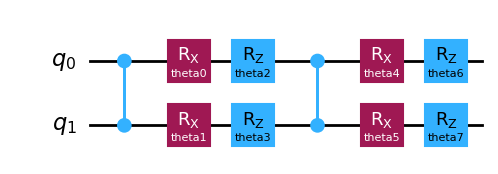

In [150]:
# Hamiltoniano

Jx = Parameter('Jx')
Jz = Parameter('Jz')
Jxx = Parameter('Jxx')
Jzz = Parameter('Jzz')
Jxz = Parameter('Jxz')
C = Parameter('C')

H = SparsePauliOp.from_list([("XI", 0.5*Jx), ("IX", 0.5*Jx), ("ZI", 0.5*Jz), ("IZ", 0.5*Jz), ("XX", 0.5*Jxx), ("ZZ", 0.5*Jzz), ("XZ", 0.5*Jxz), ("ZX", 0.5*Jxz), ("II", 0.5*C)])

'''
Valoes tabelados
https://static-content.springer.com/esm/art%3A10.1038%2Fncomms5213/MediaObjects/41467_2014_BFncomms5213_MOESM1050_ESM.pdf
'''

Jx_val = -0.2288
Jz_val = -1.0466
Jxx_val = 0.2613
Jzz_val = 0.2356
Jxz_val = 0.2288
C_val = -3.8505

# Create a dictionary of parameters and their values
hamiltonian_param_values = {
    Jx: Jx_val,
    Jz: Jz_val,
    Jxx: Jxx_val,
    Jzz: Jzz_val,
    Jxz: Jxz_val,
    C: C_val
}

# Bind the numerical values to the Hamiltonian
H_bound = H.assign_parameters(hamiltonian_param_values)

print("Hamiltonian com parâmetros definidos:")
H_matriz = Matrix(H_bound.to_matrix())
sympy.pprint(H_matriz)

# Circuito parametrizado para preparação de estado

theta = [Parameter('theta' + str(k)) for k in range(8)]

qr = QuantumRegister(2, 'q')
estado = QuantumCircuit(qr)
for k in range(8):
    if k%4 == 0:
        estado.cz(qr[0], qr[1])
        estado.rx(theta[k], qr[0])
    elif k%4 == 1:
        estado.rx(theta[k], qr[1])
    elif k%4 == 2:
        estado.rz(theta[k], qr[0])
    elif k%4 == 3:
        estado.rz(theta[k], qr[1])

print("Circuito de preparação do estado inicial:")
display(estado.draw('mpl'))

In [151]:
'''
Implementação do VQE
'''

# Empacotamento da função E_parametrico para uso no scipy.optimize.minimize
def E_parametrico_reduzida(parametros_otimizaveis, estado_qc_fixed, observavel_op_fixed, params_observavel_op_fixed, aer_flag_fixed, backend_fixed, shots_fixed):
    # optim_params are the parameters for the quantum state preparation circuit
    return E_parametrico(estado_qc = estado_qc_fixed,
                           observavel_op = observavel_op_fixed,
                           params_estado_qc = parametros_otimizaveis,
                           params_observavel_op = params_observavel_op_fixed,
                           aer_flag = aer_flag_fixed,
                           backend = backend_fixed,
                           shots = shots_fixed)


#################################################################################

# Observavel
observavel = H_bound.copy()
print("Observavel:")
print(observavel)

# Parâmetros de preparação do estado quântico inicial
parametros_do_estado_inicial = [0 for _ in range(8)]
parametros_do_observavel = None # H_bound já fixou o parâmetro de H

# Loop de otimização híbrida
resultado = minimize(E_parametrico_reduzida, parametros_do_estado_inicial,
                     args=(estado, # estado_qc_fixed (now correctly the 2-qubit circuit)
                           observavel, # observavel_op_fixed
                           parametros_do_observavel, # params_observavel_op_fixed
                           True, # aer_flag_fixed
                           None, # backend_fixed
                           2**20), # shots_fixed
                     tol = 1/2**12, method="COBYLA")

print("Resultado da otimização:")
print(resultado)


Observavel:
SparsePauliOp(['XI', 'IX', 'ZI', 'IZ', 'XX', 'ZZ', 'XZ', 'ZX', 'II'],
              coeffs=[-0.1144 +0.j, -0.1144 +0.j, -0.5233 +0.j, -0.5233 +0.j,  0.13065+0.j,
  0.1178 +0.j,  0.1144 +0.j,  0.1144 +0.j, -1.92525+0.j])
Resultado da otimização:
 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -2.8631617431640626
       x: [ 1.052e+00 -3.454e-02  7.052e-04 -3.998e-03  5.517e-05
            2.134e-03  3.485e-03 -1.442e-03]
    nfev: 62
   maxcv: 0.0


********************************
Estado fundamental:


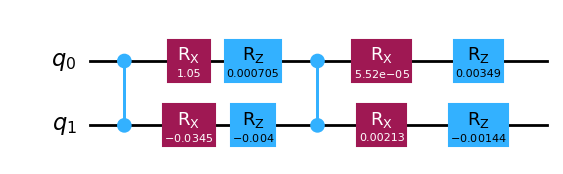

<IPython.core.display.Latex object>

Energia fundamental:
-2.8631617431640626


In [152]:
'''
Impressão do estado fundamental
'''
print("********************************")

from qiskit.quantum_info import Statevector

print("Estado fundamental:")

dicio_params = {theta[k] : list(resultado.x)[k] for k in range(8)}

estado_val = estado.copy().assign_parameters(dicio_params)
display(estado_val.draw('mpl'))

vetorestado = Statevector.from_instruction(qc_estado_val)
display(vetorestado.draw('latex'))

print("Energia fundamental:")
print(resultado.fun)